## Importing Packages And Dataset

In [ ]:
!pip install evaluate

In [2]:
from huggingface_hub import login
from datasets import load_dataset
from transformers import AutoTokenizer
from itertools import chain
import torch
from torch.utils.data import DataLoader
from transformers import DataCollatorForMultipleChoice, AutoModelForMultipleChoice, TrainingArguments, Trainer
from tqdm import tqdm
from peft import LoraConfig, get_peft_model
import numpy as np
import evaluate
from transformers import TrainingArguments
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
login(token="YOUR_TOKEN_HERE")
dataset = load_dataset("swag", "regular")

In [4]:
for i in range(2):
    sample = dataset["train"][i]
    print(f"Sample {i+1}:")
    print(f"Context (sent1): {sample['sent1']}")
    print(f"Continuation (sent2): {sample['sent2']}")
    print(f"Options: {sample['ending0']}, {sample['ending1']}, {sample['ending2']}, {sample['ending3']}")
    print(f"Correct Answer (label): {sample['label']}")
    print()

Sample 1:
Context (sent1): Members of the procession walk down the street holding small horn brass instruments.
Continuation (sent2): A drum line
Options: passes by walking down the street playing their instruments., has heard approaching them., arrives and they're outside dancing and asleep., turns the lead singer watches the performance.
Correct Answer (label): 0

Sample 2:
Context (sent1): A drum line passes by walking down the street playing their instruments.
Continuation (sent2): Members of the procession
Options: are playing ping pong and celebrating one left each in quick., wait slowly towards the cadets., continues to play as well along the crowd along with the band being interviewed., continue to play marching, interspersed.
Correct Answer (label): 3



## Analysing The Dataset And Performing Exploratory Data Analysis

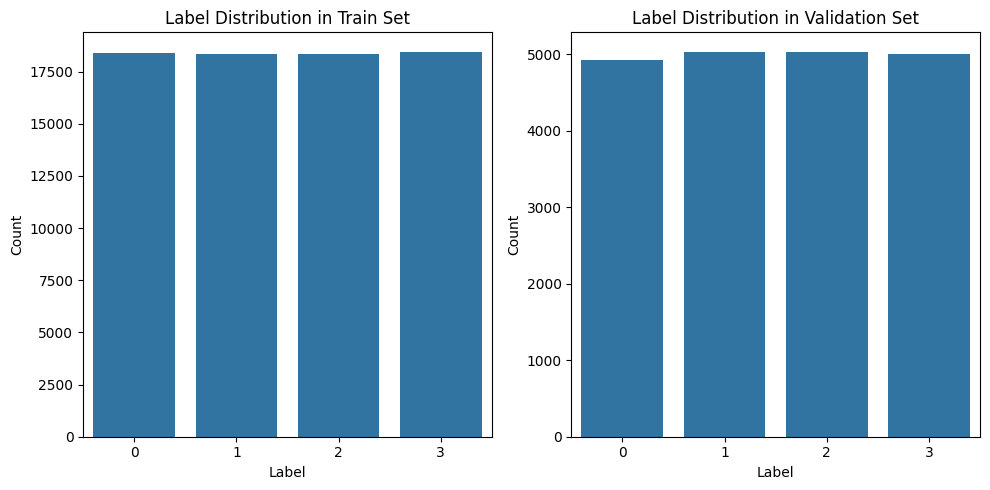

In [5]:
train_labels = dataset["train"]["label"]
validation_labels = dataset["validation"]["label"]

train_label_counts = Counter(train_labels)
validation_label_counts = Counter(validation_labels)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=list(train_label_counts.keys()), y=list(train_label_counts.values()))
plt.title("Label Distribution in Train Set")
plt.xlabel("Label")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.barplot(x=list(validation_label_counts.keys()), y=list(validation_label_counts.values()))
plt.title("Label Distribution in Validation Set")
plt.xlabel("Label")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

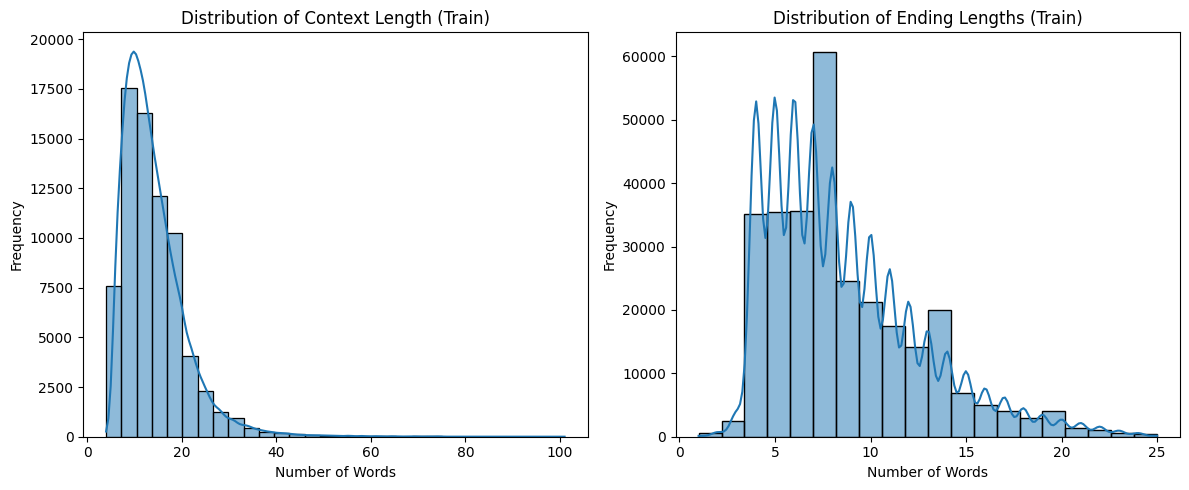

In [6]:
def get_sentence_length(example):
    context = example["sent1"] + " " + example["sent2"]
    endings = [example[f"ending{i}"] for i in range(4)]
    context_length = len(context.split())
    ending_lengths = [len(ending.split()) for ending in endings]
    return context_length, ending_lengths

train_context_lengths = []
train_ending_lengths = []
for example in dataset["train"]:
    ctx_len, end_lens = get_sentence_length(example)
    train_context_lengths.append(ctx_len)
    train_ending_lengths.extend(end_lens)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(train_context_lengths, bins=30, kde=True)
plt.title("Distribution of Context Length (Train)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(train_ending_lengths, bins=20, kde=True)
plt.title("Distribution of Ending Lengths (Train)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The questions are unifromly distributed according the their answer labels. Also looks like the length of uestions and their ending options follow a exponential shaped distribution.

## Preprocessing The Dataset

In [7]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)

def preprocess_swag_batch(examples):
    endings = ["ending0", "ending1", "ending2", "ending3"]

    contexts_per_example = [
        f"{s1} {s2}" for s1, s2 in zip(examples["sent1"], examples["sent2"])
    ]

    first_sentences = [
        [ctx] * 4 for ctx in contexts_per_example
    ]
    second_sentences = [
        [examples[end][i] for end in endings]
        for i in range(len(examples["sent1"]))
    ]

    first_sentences_flat = list(chain.from_iterable(first_sentences))
    second_sentences_flat = list(chain.from_iterable(second_sentences))

    tokenized = tokenizer(
        first_sentences_flat,
        second_sentences_flat,
        truncation=True
    )

    num_examples = len(examples["sent1"])
    result = {
        k: [v[i:i+4] for i in range(0, 4 * num_examples, 4)]
        for k, v in tokenized.items()
    }

    result["labels"] = examples["label"]
    return result


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
remove_cols = dataset["train"].column_names

encoded_datasets = dataset.map(
    preprocess_swag_batch,
    batched=True,
    remove_columns=remove_cols
)

Map:   0%|          | 0/73546 [00:00<?, ? examples/s]

Map:   0%|          | 0/20006 [00:00<?, ? examples/s]

Map:   0%|          | 0/20005 [00:00<?, ? examples/s]

In [9]:
example = encoded_datasets["train"][150]
for k, v in example.items():
    if k != "labels":
        print(k, "=>", type(v), "len:", len(v), "| choice[0] len:", len(v[0]))
print("label =>", example["labels"])

input_ids => <class 'list'> len: 4 | choice[0] len: 23
token_type_ids => <class 'list'> len: 4 | choice[0] len: 23
attention_mask => <class 'list'> len: 4 | choice[0] len: 23
label => 0


In [10]:
data_collator = DataCollatorForMultipleChoice(
    tokenizer=tokenizer,
    pad_to_multiple_of=8
)

train_dataloader = DataLoader(
    encoded_datasets["train"],
    batch_size=8,
    shuffle=True,
    collate_fn=data_collator
)

I defined the preprocess_swag_batch function, applied it on the dataset and imposed padding mechanism using the datacollator method.

In [11]:
batch = next(iter(train_dataloader))
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape)
    else:
        print(k, type(v))

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


input_ids torch.Size([8, 4, 48])
token_type_ids torch.Size([8, 4, 48])
attention_mask torch.Size([8, 4, 48])
labels torch.Size([8])


## Loading The Model And Evaluating It On The Validation Set

In [12]:
model = AutoModelForMultipleChoice.from_pretrained("google-bert/bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForMultipleChoice were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
val_dataloader = DataLoader(
    encoded_datasets["validation"],
    batch_size=8,
    shuffle=False,
    collate_fn=DataCollatorForMultipleChoice(tokenizer=tokenizer)
)
model.eval()

single_example = encoded_datasets["validation"][1090]

raw_ex = dataset["validation"][1090]

print(f"Question: {raw_ex['sent1']}, {raw_ex['sent2']}")

for i in range(4):
    print(f"Option {i}: {raw_ex[f'ending{i}']}")

print(f"\n🔑 Correct answer: {raw_ex['label']}")


single_batch = DataCollatorForMultipleChoice(tokenizer=tokenizer)([single_example])

with torch.no_grad():
    outputs = model(**{k: v for k, v in single_batch.items() if k != "labels"})
    logits = outputs.logits

predicted = torch.argmax(logits, dim=1).item()
true_label = single_batch["labels"].item()

print(f"🔍 Predicted: {predicted} | Ground Truth: {true_label}")
if predicted == true_label:
    print("✅ Model prediction is correct.")
else:
    print("❌ Model prediction is incorrect.")


Question: Someone hangs his head and nods., She
Option 0: smiles and offers his hand.
Option 1: crosses to someone's apartment in bed.
Option 2: sits down from him.
Option 3: steps out of the kitchen.

🔑 Correct answer: 3
🔍 Predicted: 3 | Ground Truth: 3
✅ Model prediction is correct.


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def to_device_batch(batch, device):
    return {k: v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

correct = 0
total = 0

with torch.inference_mode():
    for batch in tqdm(val_dataloader, desc="Validating"):
        batch = to_device_batch(batch, device)

        labels_key = "labels" if "labels" in batch else "label"
        labels = batch.pop(labels_key)

        outputs = model(**batch)
        predictions = outputs.logits.argmax(dim=-1)

        correct += (predictions == labels).sum().cpu().item()
        total += labels.size(0)

accuracy = correct / total if total > 0 else 0.0
print(f"📊 Validation Accuracy: {accuracy:.4f}")


Validating: 100%|██████████| 2501/2501 [03:26<00:00, 12.13it/s]

📊 Validation Accuracy: 0.1522


As we can see, the primary accuracy of the model is 13% which is insanely low, even lower than a random classifier which definitely tends to approach 25% accuracy. This means the questions are tricky and are designed to decieve our model. We have to strenghen the model using ICL and LoRA methods.

## Using In-Context-Learning

In [15]:
from random import choice

def build_fewshot_val_dataloader(tokenizer, encoded_val, raw_val, raw_train_dataset, k=4, batch_size=8):
    label_groups = {i: [] for i in range(4)}
    for ex in raw_train_dataset:
        label_groups[ex['label']].append(ex)

    def collate_fewshot(batch_indices):
        choice_input_ids, choice_attention_mask, labels = [], [], []
        for idx in batch_indices:
            raw_ex = raw_val[idx]

            few_shot_examples = [choice(label_groups[j]) for j in range(4)]
            context_parts = []
            for fs in few_shot_examples:
                q = f"{fs['sent1']} {fs['sent2']}"
                a = fs[f"ending{fs['label']}"]
                context_parts.append(f"Q: {q}\nA: {a}")
            context_text = "\n\n".join(context_parts)

            base_question = f"{raw_ex['sent1']} {raw_ex['sent2']}"
            choice_texts = [f"{context_text}\n\nQ: {base_question}\nA: {raw_ex[f'ending{k}']}" for k in range(4)]

            tokenized = tokenizer(choice_texts, padding="max_length", truncation=True, return_tensors="pt")
            choice_input_ids.append(tokenized["input_ids"])
            choice_attention_mask.append(tokenized["attention_mask"])
            labels.append(raw_ex["label"])

        return {
            "input_ids": torch.stack(choice_input_ids),
            "attention_mask": torch.stack(choice_attention_mask),
            "labels": torch.tensor(labels)
        }

    return DataLoader(range(len(raw_val)), batch_size=batch_size, shuffle=False, collate_fn=collate_fewshot)


def build_zeroshot_reasoning_val_dataloader(tokenizer, encoded_val, raw_val, batch_size=8):
    def collate_chain_of_thought(batch_indices):
        choice_input_ids, choice_attention_mask, labels = [], [], []
        for idx in batch_indices:
            raw_ex = raw_val[idx]
            base_question = f"{raw_ex['sent1']} {raw_ex['sent2']} Let's think step by step."
            choice_texts = [f"{base_question} Option: {raw_ex[f'ending{k}']}" for k in range(4)]

            tokenized = tokenizer(choice_texts, padding="max_length", truncation=True, return_tensors="pt")
            choice_input_ids.append(tokenized["input_ids"])
            choice_attention_mask.append(tokenized["attention_mask"])
            labels.append(raw_ex["label"])

        return {
            "input_ids": torch.stack(choice_input_ids),
            "attention_mask": torch.stack(choice_attention_mask),
            "labels": torch.tensor(labels)
        }

    return DataLoader(range(len(raw_val)), batch_size=batch_size, shuffle=False, collate_fn=collate_chain_of_thought)


def build_instruction_tuned_val_dataloader(tokenizer, encoded_val, raw_val, batch_size=8):
    instruction = "Read the question and choose the most plausible ending."

    def collate_instruction(batch_indices):
        choice_input_ids, choice_attention_mask, labels = [], [], []
        for idx in batch_indices:
            raw_ex = raw_val[idx]
            base_question = f"{instruction}\n{raw_ex['sent1']} {raw_ex['sent2']}"
            choice_texts = [f"{base_question}\nOption: {raw_ex[f'ending{k}']}" for k in range(4)]

            tokenized = tokenizer(choice_texts, padding="max_length", truncation=True, return_tensors="pt")
            choice_input_ids.append(tokenized["input_ids"])
            choice_attention_mask.append(tokenized["attention_mask"])
            labels.append(raw_ex["label"])

        return {
            "input_ids": torch.stack(choice_input_ids),
            "attention_mask": torch.stack(choice_attention_mask),
            "labels": torch.tensor(labels)
        }

    return DataLoader(range(len(raw_val)), batch_size=batch_size, shuffle=False, collate_fn=collate_instruction)

def evaluate(model, dataloader, device):
    correct, total = 0, 0
    model = model.to(device)
    model.eval()
    with torch.inference_mode():
        for batch in tqdm(dataloader, desc="Validating"):
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
            labels = batch.pop("labels")

            outputs = model(**batch)
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


In [16]:
# Few-Shot
val_dl_fewshot = build_fewshot_val_dataloader(tokenizer, encoded_datasets["validation"], dataset["validation"], dataset["train"])
# Zero-Shot Reasoning
val_dl_zeroshot = build_zeroshot_reasoning_val_dataloader(tokenizer, encoded_datasets["validation"], dataset["validation"])
# Instruction-Tuned
val_dl_instruction = build_instruction_tuned_val_dataloader(tokenizer, encoded_datasets["validation"], dataset["validation"])


print("Few-Shot Acc:", evaluate(model, val_dl_fewshot, device))
print("Zero-Shot Reasoning Acc:", evaluate(model, val_dl_zeroshot, device))
print("Instruction-Tuned Acc:", evaluate(model, val_dl_instruction, device))

Validating: 100%|██████████| 2501/2501 [41:16<00:00,  1.01it/s]


Few-Shot Acc: 0.27921623512946114


Validating: 100%|██████████| 2501/2501 [40:52<00:00,  1.02it/s]


Zero-Shot Reasoning Acc: 0.24597620713785864


Validating: 100%|██████████| 2501/2501 [41:05<00:00,  1.01it/s]

Instruction-Tuned Acc: 0.25867239828051586


As we can see, using ICL improved the model performance significantly and this shows the importnce of explaining the procedure of thinking to the model.

## Fine-tuning Bert Model

In [17]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)

fine_tuned_model = get_peft_model(model, lora_config)


In [18]:
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     preds = np.argmax(logits, axis=1)

#     acc = accuracy.compute(predictions=preds, references=labels)["accuracy"]

#     probs = np.exp(logits) / np.exp(logits).sum(-1, keepdims=True)
#     chosen_probs = np.take_along_axis(probs, preds[:, None], axis=1).squeeze()
#     mean_loss = -np.log(chosen_probs + 1e-12).mean()
#     perplexity = np.exp(mean_loss)

#     return {"accuracy": acc, "perplexity": perplexity}

In [25]:
import numpy as np
from evaluate import load

accuracy = load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    # Accuracy
    acc = accuracy.compute(predictions=preds, references=labels)["accuracy"]

    # Convert logits to probabilities
    probs = np.exp(logits - np.max(logits, axis=1, keepdims=True))  # numerical stability
    probs = probs / probs.sum(-1, keepdims=True)

    # Select the probability of the true label (not the predicted one!)
    chosen_probs = np.take_along_axis(probs, labels[:, None], axis=1).squeeze()

    # Negative log-likelihood
    mean_loss = -np.log(chosen_probs + 1e-12).mean()

    # Perplexity
    perplexity = np.exp(mean_loss)

    return {"accuracy": acc, "perplexity": perplexity}


In [19]:
training_args = TrainingArguments(
    output_dir="./results",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    fp16=True,
    report_to=[]
)

In [20]:
trainer_lora = Trainer(
    model=fine_tuned_model,
    args=training_args,
    train_dataset=encoded_datasets["train"],
    eval_dataset=encoded_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_lora.train()

/tmp/ipython-input-1011803367.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_lora = Trainer(


Step,Training Loss
50,1.401600
100,1.356800
150,1.323800
200,1.268000
250,1.213900
300,1.167100
350,1.158300
400,1.101200
450,1.088600
500,1.074500


TrainOutput(global_step=2300, training_loss=1.0261212191374405, metrics={'train_runtime': 1169.5399, 'train_samples_per_second': 125.769, 'train_steps_per_second': 1.967, 'total_flos': 1.5964152441485568e+16, 'train_loss': 1.0261212191374405, 'epoch': 2.0})

Final Results: {'eval_loss': 0.792994499206543, 'eval_accuracy': 0.6939418174547636, 'eval_perplexity': 1.6089990139007568, 'eval_runtime': 80.7338, 'eval_samples_per_second': 247.802, 'eval_steps_per_second': 30.978, 'epoch': 2.0}


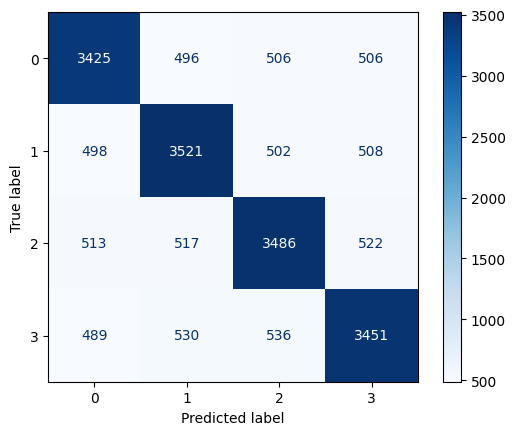

In [27]:
results = trainer_lora.evaluate()
print("Final Results:", results)

# Confusion Matrix
preds = np.argmax(trainer_lora.predict(encoded_datasets["validation"]).predictions, axis=1)
labels = np.array(encoded_datasets["validation"]["labels"])
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

It's also obvious that fine-tuning the model enhances model accuracy significantly. Even more than the ICL because we are directly improving the weights according to our task.

## Applying Both ICL and LoRA Methods Together

In [31]:
from sklearn.metrics import classification_report, accuracy_score

val_dl_fewshot_ft = build_fewshot_val_dataloader(
    tokenizer,
    encoded_datasets["validation"],
    dataset["validation"],
    dataset["train"]
)

print("Fine-Tuned + Few-Shot ICL Acc:",
      evaluate(fine_tuned_model, val_dl_fewshot_ft, device))

preds_ft_icl = np.argmax(
    trainer_lora.predict(encoded_datasets["validation"]).predictions, axis=1
)
labels_ft = np.array(encoded_datasets["validation"]["labels"])

print(classification_report(labels_ft, preds_ft_icl, digits=4))



Validating: 100%|██████████| 2501/2501 [11:10<00:00,  3.73it/s]

Fine-Tuned + Few-Shot ICL Acc: 0.46021193641907426


              precision    recall  f1-score   support

           0     0.6954    0.6943    0.6949      4933
           1     0.6953    0.7001    0.6977      5029
           2     0.6930    0.6919    0.6925      5038
           3     0.6920    0.6894    0.6907      5006

    accuracy                         0.6939     20006
   macro avg     0.6939    0.6939    0.6939     20006
weighted avg     0.6939    0.6939    0.6939     20006

